In [1078]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


In [1079]:
df=pd.read_csv("/content/Titanic Dataset.csv")

In [1080]:
df.shape

(891, 12)

In [1081]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1082]:
df.isna().count()

,0
PassengerId,891
Survived,891
Pclass,891
Name,891
Sex,891
Age,891
SibSp,891
Parch,891
Ticket,891
Fare,891


In [1083]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [1084]:
df=df.drop(columns=["PassengerId","Cabin","Name","Ticket"], axis=1)

In [1085]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [1086]:
df['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

<Axes: ylabel='Age'>

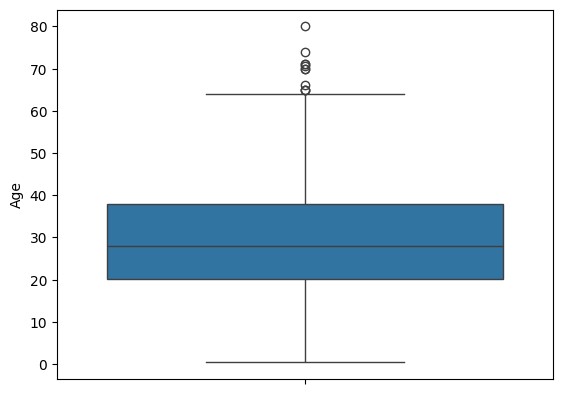

In [1087]:
sns.boxplot(df['Age'])

In [1088]:
df['Age']=df['Age'].mask(df['Age']>60,60)

(array([ 47.,  22.,  70., 138., 132., 110.,  66.,  49.,  38.,  42.]),
 array([ 0.42 ,  6.378, 12.336, 18.294, 24.252, 30.21 , 36.168, 42.126,
        48.084, 54.042, 60.   ]),
 <BarContainer object of 10 artists>)

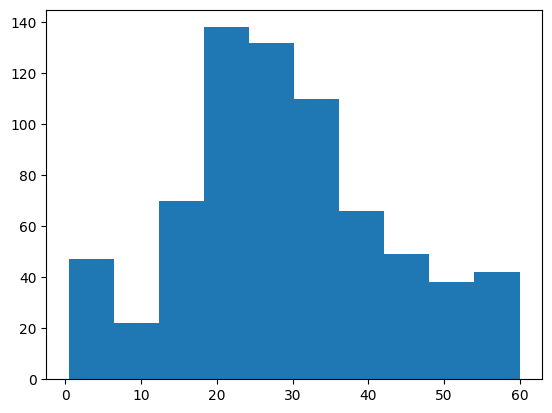

In [1089]:
plt.hist(df['Age'])

In [1090]:
df['Age']=df['Age'].fillna(df['Age'].mean())

(array([ 47.,  22.,  70., 138., 309., 110.,  66.,  49.,  38.,  42.]),
 array([ 0.42 ,  6.378, 12.336, 18.294, 24.252, 30.21 , 36.168, 42.126,
        48.084, 54.042, 60.   ]),
 <BarContainer object of 10 artists>)

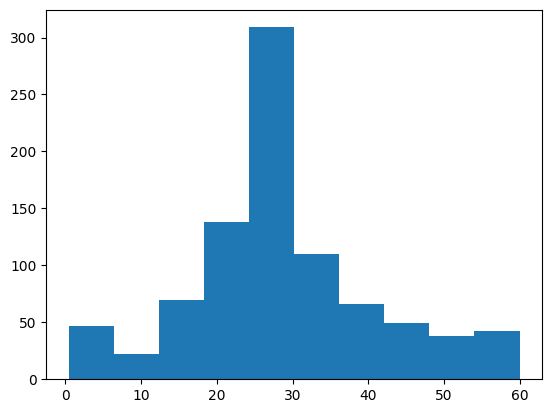

In [1091]:
plt.hist(df['Age'])

In [1092]:
df['Pclass']=df['Pclass'].map({1:'F',2:'S',3:'T'})

In [1093]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,T,male,22.0,1,0,7.2500,S
1,1,F,female,38.0,1,0,71.2833,C
2,1,T,female,26.0,0,0,7.9250,S
3,1,F,female,35.0,1,0,53.1000,S
4,0,T,male,35.0,0,0,8.0500,S


In [1094]:
df.shape

(891, 8)

In [1095]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,T,male,22.0,1,0,7.2500,S
1,1,F,female,38.0,1,0,71.2833,C
2,1,T,female,26.0,0,0,7.9250,S
3,1,F,female,35.0,1,0,53.1000,S
4,0,T,male,35.0,0,0,8.0500,S


In [1096]:
df.groupby(['Sex'])['Survived'].count()

,Survived
Sex,
female,314
male,577


In [1097]:
df['Sex']=df['Sex'].map({'male':0,'female':1})

In [1098]:
df=pd.get_dummies(df)

In [1099]:
df.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_F,Pclass_S,Pclass_T,Embarked_C,Embarked_Q,Embarked_S
0,0,0,22.0,1,0,7.2500,False,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,False,True,False,False
2,1,1,26.0,0,0,7.9250,False,False,True,False,False,True
3,1,1,35.0,1,0,53.1000,True,False,False,False,False,True
4,0,0,35.0,0,0,8.0500,False,False,True,False,False,True


In [1100]:
cor_data=df.corr()
cor_data

,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_F,Pclass_S,Pclass_T,Embarked_C,Embarked_Q,Embarked_S
Survived,1.000000,0.543351,-0.067724,-0.035322,0.081629,0.257307,0.285904,0.093349,-0.322308,0.168240,0.003650,-0.155660
Sex,0.543351,1.000000,-0.079357,0.114631,0.245489,0.182333,0.098013,0.064746,-0.137143,0.082853,0.074115,-0.125722
Age,-0.067724,-0.079357,1.000000,-0.236115,-0.182158,0.094102,0.320709,0.009913,-0.284392,0.032417,-0.017579,-0.025058
SibSp,-0.035322,0.114631,-0.236115,1.000000,0.414838,0.159651,-0.054582,-0.055932,0.092548,-0.059528,-0.026354,0.070941
Parch,0.081629,0.245489,-0.182158,0.414838,1.000000,0.216225,-0.017633,-0.000734,0.015790,-0.011069,-0.081228,0.063036
Fare,0.257307,0.182333,0.094102,0.159651,0.216225,1.000000,0.591711,-0.118557,-0.413333,0.269335,-0.117216,-0.166603
Pclass_F,0.285904,0.098013,0.320709,-0.054582,-0.017633,0.591711,1.000000,-0.288585,-0.626738,0.296423,-0.155342,-0.170379
Pclass_S,0.093349,0.064746,0.009913,-0.055932,-0.000734,-0.118557,-0.288585,1.000000,-0.565210,-0.125416,-0.127301,0.192061
Pclass_T,-0.322308,-0.137143,-0.284392,0.092548,0.015790,-0.413333,-0.626738,-0.565210,1.000000,-0.153329,0.237449,-0.009511
Embarked_C,0.168240,0.082853,0.032417,-0.059528,-0.011069,0.269335,0.296423,-0.125416,-0.153329,1.000000,-0.148258,-0.778359


<Axes: >

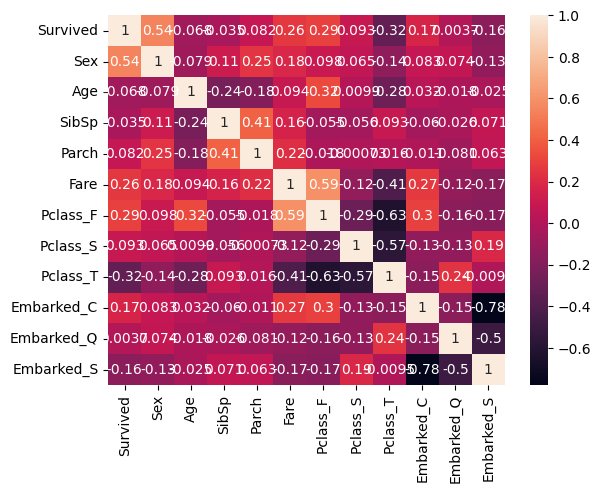

In [1101]:
sns.heatmap(cor_data,annot=True)

In [1102]:
X = df.drop('Survived', axis=1)

y = df['Survived']

In [1103]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [1104]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [1105]:
model=LogisticRegression()
model.fit(X_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [1106]:
y_pred = model.predict(X_test)

In [1107]:
y_pred

array([0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0])

In [1108]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8156424581005587


In [1109]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[95 15]
 [18 51]]


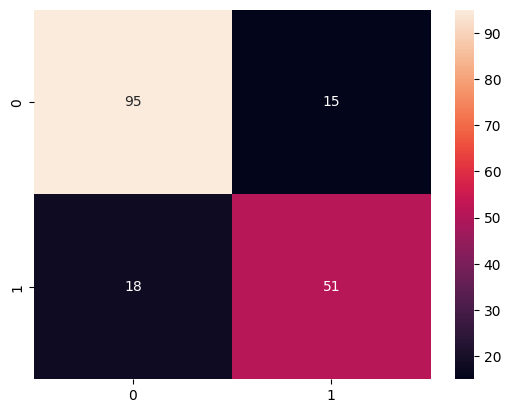

In [1110]:
sns.heatmap(cm, annot=True)
plt.show()

In [1111]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8268156424581006
